<a href="https://colab.research.google.com/github/asharma1893/Msc-Research/blob/main/Anjali_Sharma_Bangalore_House_Price_Prediction_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Bangalore House Price Prediction
## MSc Data Science Thesis — Anjali Sharma
### Liverpool John Moores University & upGrad, 2026

**Dataset:** Bengaluru House Price Dataset (Kaggle, 13,320 records)  

## Section 1: Data Loading and Initial Cleaning

In [1]:
# Install xgboost if needed
# !pip install xgboost -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

plt.rcParams.update({
    'font.size': 16, 'axes.titlesize': 20, 'axes.titleweight': 'bold',
    'axes.labelsize': 17, 'xtick.labelsize': 15, 'ytick.labelsize': 15,
    'legend.fontsize': 14, 'figure.dpi': 120,
})
print("Libraries loaded.")

Libraries loaded.


### 1.1 Load raw data

In [2]:
df = pd.read_csv('bengaluru_house_prices.csv')
print("Raw shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nMissing values:")
print(df.isnull().sum())
display(df.head())

Raw shape: (13320, 9)

Columns: ['area_type', 'availability', 'location', 'size', 'society', 'total_sqft', 'bath', 'balcony', 'price']

Missing values:
area_type          0
availability       0
location           1
size              16
society         5502
total_sqft         0
bath              73
balcony          609
price              0
dtype: int64


,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00


### 1.2 Clean column names and remove duplicates

In [3]:
df.columns = df.columns.str.strip()

for col in ['area_type', 'availability', 'location', 'size', 'society']:
    df[col] = df[col].astype(str).str.strip()

df.replace(['nan', 'None', 'NULL', ''], np.nan, inplace=True)
df = df.drop_duplicates()

print("Shape after removing duplicates:", df.shape)
display(df.head())

Shape after removing duplicates: (12790, 9)


,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00


### 1.3 Feature extraction — BHK and square footage

In [4]:
def extract_bhk(size_value):
    """Extract numeric BHK count from size column. Handles '2 BHK', '4 Bedroom', '1 RK'."""
    if pd.isna(size_value):
        return np.nan
    match = re.search(r'(\d+)', str(size_value))
    return float(match.group(1)) if match else np.nan

def convert_sqft_to_num(x):
    """Convert total_sqft to a single number. Handles ranges like '2100-2850' by taking midpoint."""
    if pd.isna(x):
        return np.nan
    x = str(x).strip()
    if '-' in x:
        parts = x.split('-')
        if len(parts) == 2:
            try:
                return (float(parts[0].strip()) + float(parts[1].strip())) / 2
            except:
                return np.nan
    try:
        return float(x)
    except:
        return np.nan

df['bhk']            = df['size'].apply(extract_bhk)
df['total_sqft_num'] = df['total_sqft'].apply(convert_sqft_to_num)
df['location']       = df['location'].astype(str).str.strip()
df['location']       = df['location'].replace('nan', np.nan)
df = df.dropna(subset=['location', 'size', 'bath', 'price', 'bhk', 'total_sqft_num'])

print("Shape after dropping nulls:", df.shape)

# Derived features
df['price_per_sqft'] = (df['price'] * 100000) / df['total_sqft_num']
df['total_rooms']    = df['bhk'] + df['bath'].fillna(0) + df['balcony'].fillna(0)
df['balcony']        = df['balcony'].fillna(df['balcony'].median())
df['society']        = df['society'].fillna('Unknown')
display(df.head())

Shape after dropping nulls: (12670, 11)


,area_type,availability,location,size,society,total_sqft,bath,balcony,price,bhk,total_sqft_num,price_per_sqft,total_rooms
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07,2.0,1056.0,3699.810606,5.0
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00,4.0,2600.0,4615.384615,12.0
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,Unknown,1440,2.0,3.0,62.00,3.0,1440.0,4305.555556,8.0
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00,3.0,1521.0,6245.890861,7.0
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,Unknown,1200,2.0,1.0,51.00,2.0,1200.0,4250.000000,5.0


### 1.4 Summary statistics

In [5]:
print("Data types:")
print(df.dtypes)
print("\nSummary statistics:")
display(df[['price', 'total_sqft_num', 'bath', 'balcony', 'bhk', 'price_per_sqft']].describe())

Data types:
area_type          object
availability       object
location           object
size               object
society            object
total_sqft         object
bath              float64
balcony           float64
price             float64
bhk               float64
total_sqft_num    float64
price_per_sqft    float64
total_rooms       float64
dtype: object

Summary statistics:


,price,total_sqft_num,bath,balcony,bhk,price_per_sqft
count,12670.000000,12670.000000,12670.000000,12670.000000,12670.000000,1.267000e+04
mean,114.037128,1565.183970,2.707182,1.601026,2.814996,8.037644e+03
std,151.721743,1258.932832,1.355263,0.809028,1.309852,1.089341e+05
min,8.000000,1.000000,1.000000,0.000000,1.000000,2.678298e+02
25%,50.000000,1100.000000,2.000000,1.000000,2.000000,4.298705e+03
50%,73.000000,1280.000000,2.000000,2.000000,3.000000,5.484552e+03
75%,120.000000,1685.000000,3.000000,2.000000,3.000000,7.404795e+03
max,3600.000000,52272.000000,40.000000,3.000000,43.000000,1.200000e+07


### 1.5 Outlier removal

Removing clearly invalid records using these rules (same as original notebook):
- Properties ≤ 300 sqft total
- More than 16 bedrooms or bathrooms (data entry errors)  
- Less than 300 sqft per bedroom (implausibly small rooms)
- Price per sqft outside IQR range (extreme outliers)

In [6]:
before = len(df)

df = df[df['total_sqft_num'] > 300]
df = df[df['bhk'] <= 16]
df = df[df['bath'] <= 16]
df = df[df['total_sqft_num'] / df['bhk'] >= 300]

Q1  = df['price_per_sqft'].quantile(0.25)
Q3  = df['price_per_sqft'].quantile(0.75)
IQR = Q3 - Q1
df = df[(df['price_per_sqft'] >= Q1 - 1.5*IQR) & (df['price_per_sqft'] <= Q3 + 1.5*IQR)]

print(f"Before outlier removal: {before:,}")
print(f"After outlier removal:  {len(df):,}")
print(f"Removed: {before - len(df):,} records ({(before-len(df))/before*100:.1f}%)")

Before outlier removal: 12,670
After outlier removal:  10,959
Removed: 1,711 records (13.5%)


### 1.6 Location grouping

In [7]:
location_counts  = df['location'].value_counts()
rare_locations   = location_counts[location_counts <= 10].index
df['location_grouped'] = df['location'].apply(lambda x: 'Other' if x in rare_locations else x)

print("Unique original locations:", df['location'].nunique())
print("Unique grouped locations: ", df['location_grouped'].nunique())
print("\nTop 30 locations by listing count:")
display(df['location_grouped'].value_counts().head(30))

Unique original locations: 1106
Unique grouped locations:  201

Top 30 locations by listing count:


,count
location_grouped,
Other,2420
Whitefield,481
Sarjapur Road,355
Electronic City,279
Kanakpura Road,238
Thanisandra,228
Yelahanka,201
Marathahalli,161
Raja Rajeshwari Nagar,154


In [8]:
df.to_csv('bengaluru_cleaned_stage1.csv', index=False)
print("Saved: bengaluru_cleaned_stage1.csv | shape:", df.shape)

Saved: bengaluru_cleaned_stage1.csv | shape: (10959, 14)


---
## Section 2: Expanded Spatial Feature Engineering

### 2.1 Load cleaned data

In [9]:
df = pd.read_csv('bengaluru_cleaned_stage1.csv')
print("Cleaned dataset shape:", df.shape)
display(df.head())

Cleaned dataset shape: (10959, 14)


,area_type,availability,location,size,society,total_sqft,bath,balcony,price,bhk,total_sqft_num,price_per_sqft,total_rooms,location_grouped
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07,2.0,1056.0,3699.810606,5.0,Electronic City Phase II
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00,4.0,2600.0,4615.384615,12.0,Chikka Tirupathi
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,Unknown,1440,2.0,3.0,62.00,3.0,1440.0,4305.555556,8.0,Uttarahalli
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00,3.0,1521.0,6245.890861,7.0,Lingadheeranahalli
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,Unknown,1200,2.0,1.0,51.00,2.0,1200.0,4250.000000,5.0,Kothanur


### 2.2 Coordinate lookup dictionary

This dictionary covers all ~200 named Bangalore location groups,  
targeting 80%+ spatial coverage.

In [10]:
location_coords = {

    # ── ORIGINAL 33 ───────────────────────────────────────────────────────────
    "Electronic City":           (12.8399, 77.6770),
    "Electronic City Phase II":  (12.8350, 77.6762),
    "Whitefield":                (12.9698, 77.7499),
    "Marathahalli":              (12.9591, 77.6974),
    "Bellandur":                 (12.9250, 77.6762),
    "Sarjapur Road":             (12.9008, 77.6826),
    "HSR Layout":                (12.9116, 77.6474),
    "Koramangala":               (12.9352, 77.6245),
    "Indira Nagar":              (12.9784, 77.6408),
    "Jayanagar":                 (12.9250, 77.5938),
    "JP Nagar":                  (12.9081, 77.5857),
    "Banashankari":              (12.9255, 77.5468),
    "Uttarahalli":               (12.9066, 77.5473),
    "Yelahanka":                 (13.1007, 77.5963),
    "Hebbal":                    (13.0358, 77.5970),
    "Thanisandra":               (13.0465, 77.6200),
    "Hennur":                    (13.0269, 77.6469),
    "RT Nagar":                  (13.0247, 77.5944),
    "Malleshwaram":              (13.0035, 77.5706),
    "Rajaji Nagar":              (12.9910, 77.5550),
    "Vijayanagar":               (12.9719, 77.5340),
    "Nagarbhavi":                (12.9659, 77.5069),
    "Kengeri":                   (12.9141, 77.4842),
    "Bommanahalli":              (12.9083, 77.6238),
    "Chandapura":                (12.8000, 77.7041),
    "Attibele":                  (12.7797, 77.7702),
    "Kanakpura Road":            (12.8874, 77.5639),
    "Basavanagudi":              (12.9417, 77.5755),
    "Brookefield":               (12.9666, 77.7172),
    "Mahadevapura":              (12.9916, 77.6992),
    "KR Puram":                  (13.0077, 77.6955),
    "Ramamurthy Nagar":          (13.0120, 77.6787),
    "CV Raman Nagar":            (12.9854, 77.6639),

    # ── HIGH-COUNT LOCATIONS MISSING FROM ORIGINAL ────────────────────────────
    "Sarjapur  Road":            (12.9008, 77.6826),  # double-space variant
    "Raja Rajeshwari Nagar":     (12.9227, 77.5197),
    "Bannerghatta Road":         (12.8933, 77.5978),
    "Hennur Road":               (13.0313, 77.6380),
    "7th Phase JP Nagar":        (12.8988, 77.5929),
    "Haralur Road":              (12.8928, 77.6745),
    "Electronics City Phase 1":  (12.8450, 77.6710),
    "Hoodi":                     (12.9859, 77.7161),
    "Sarjapur":                  (12.8607, 77.7860),

    # ── SOUTH BANGALORE ───────────────────────────────────────────────────────
    "BTM Layout":                (12.9166, 77.6101),
    "BTM 2nd Stage":             (12.9096, 77.6168),
    "Hulimavu":                  (12.8786, 77.5987),
    "Arekere":                   (12.8840, 77.6109),
    "Begur Road":                (12.8758, 77.6066),
    "Gottigere":                 (12.8577, 77.5936),
    "Gubbalala":                 (12.8729, 77.5601),
    "Hemmigepura":               (12.8868, 77.5011),
    "Kengeri Satellite Town":    (12.9054, 77.4914),
    "Subramanyapura":            (12.8986, 77.5421),
    "Talaghattapura":            (12.8562, 77.4983),
    "Judicial Layout":           (12.8980, 77.5580),
    "Konanakunte":               (12.8941, 77.5629),
    "Akshayanagar":              (12.8769, 77.6238),
    "Parappana Agrahara":        (12.8767, 77.6508),
    "Harlur":                    (12.8928, 77.6745),
    "Carmelaram":                (12.8994, 77.7236),
    "Kasavanahalli":             (12.9075, 77.7071),
    "Gunjur":                    (12.9130, 77.7537),
    "Balagere":                  (12.9494, 77.7587),
    "Panathur":                  (12.9379, 77.7098),
    "Varthur":                   (12.9393, 77.7480),
    "Dommasandra":               (12.8983, 77.7699),
    "Begur":                     (12.8711, 77.6112),

    # ── NORTH BANGALORE ───────────────────────────────────────────────────────
    "Yelahanka New Town":        (13.1008, 77.5855),
    "Kogilu":                    (13.0700, 77.6050),
    "HBR Layout":                (13.0267, 77.6348),
    "Kalyan Nagar":              (13.0266, 77.6483),
    "HRBR Layout":               (13.0240, 77.6420),
    "Jakkur":                    (13.0745, 77.5972),
    "Sahakara Nagar":            (13.0589, 77.5906),
    "Vidyaranyapura":            (13.0681, 77.5667),
    "Bagalur":                   (13.1484, 77.6764),
    "Devanahalli":               (13.2480, 77.7120),
    "Doddaballapur Road":        (13.1300, 77.5850),
    "Bettahalsoor":              (13.0484, 77.6591),
    "Babusapalaya":              (13.0350, 77.6700),
    "Horamavu":                  (13.0260, 77.6600),
    "Horamavu Agara":            (13.0310, 77.6650),
    "Kaval Byrasandra":          (13.0100, 77.6530),
    "Lingarajapuram":            (13.0029, 77.6478),
    "Narayanapura":              (13.0435, 77.6880),
    "Kothanur":                  (13.0581, 77.6131),
    "Dasarahalli":               (13.0366, 77.5158),
    "Laggere":                   (13.0028, 77.5220),
    "Peenya":                    (13.0280, 77.5150),
    "Peenya Industrial Area":    (13.0219, 77.5138),
    "Yeshwanthpur":              (13.0249, 77.5465),
    "Jalahalli":                 (13.0549, 77.5393),
    "Mathikere":                 (13.0275, 77.5608),
    "Sanjaynagar":               (13.0211, 77.5875),
    "Hebbal Kempapura":          (13.0476, 77.5893),
    "Nagawara":                  (13.0450, 77.6230),
    "Banaswadi":                 (13.0200, 77.6540),
    "Kammanahalli":              (13.0143, 77.6570),
    "Kaggadasapura":             (12.9978, 77.6772),
    "Rachenahalli":              (13.0670, 77.6186),
    "Thanisandra Main Road":     (13.0500, 77.6250),

    # ── EAST BANGALORE ────────────────────────────────────────────────────────
    "Kadugodi":                  (12.9893, 77.7711),
    "Kundalahalli":              (12.9709, 77.7114),
    "Thubarahalli":              (12.9710, 77.7257),
    "Ramagondanahalli":          (12.9975, 77.7494),
    "Nallurhalli":               (12.9641, 77.7380),
    "Garudacharpalya":           (12.9963, 77.7148),
    "Vibhutipura":               (12.9600, 77.7117),
    "Doddanekundi":              (12.9710, 77.7040),
    "Hagadur":                   (12.9802, 77.7422),
    "Munnekollal":               (12.9690, 77.7050),
    "Chikka Tirupathi":          (13.0234, 77.7890),
    "Devarabeesanahalli":        (12.9643, 77.7027),
    "ITPL":                      (12.9863, 77.7278),
    "Budigere":                  (13.0603, 77.7827),
    "Old Madras Road":           (13.0041, 77.6882),
    "Kalkere":                   (13.0237, 77.7079),
    "Sanjay Nagar":              (13.0211, 77.5875),

    # ── CENTRAL BANGALORE ─────────────────────────────────────────────────────
    "MG Road":                   (12.9756, 77.6050),
    "Residency Road":            (12.9726, 77.6018),
    "Richmond Town":             (12.9613, 77.6040),
    "Vasanth Nagar":             (12.9894, 77.5954),
    "Shivajinagar":              (12.9878, 77.6024),
    "Seshadripuram":             (12.9939, 77.5743),
    "Frazer Town":               (12.9939, 77.6209),
    "Benson Town":               (13.0055, 77.6078),
    "Cox Town":                  (13.0031, 77.6209),
    "Cleveland Town":            (12.9936, 77.6253),
    "Ulsoor":                    (12.9807, 77.6208),
    "HAL 2nd Stage":             (12.9634, 77.6571),
    "Domlur":                    (12.9606, 77.6392),
    "Old Airport Road":          (12.9594, 77.6484),
    "Murugeshpalya":             (12.9591, 77.6549),
    "Ejipura":                   (12.9461, 77.6280),
    "Vivek Nagar":               (12.9502, 77.6449),

    # ── WEST BANGALORE ────────────────────────────────────────────────────────
    "Rajajinagar":               (12.9910, 77.5550),
    "Basaveshwara Nagar":        (12.9941, 77.5365),
    "Chandra Layout":            (12.9727, 77.5191),
    "Nandini Layout":            (13.0000, 77.5290),
    "BEL Road":                  (13.0278, 77.5639),
    "Dollars Colony":            (13.0117, 77.5429),
    "Subramanyanagar":           (12.9884, 77.5393),
    "Kamakshipalya":             (12.9769, 77.5217),
    "Mahalakshmi Layout":        (13.0044, 77.5460),
    "RR Nagar":                  (12.9227, 77.5197),
    "Mysore Road":               (12.9490, 77.5226),
    "Rajarajeshwari Nagar":      (12.9227, 77.5197),
    "Nayandahalli":              (12.9441, 77.5155),
    "Kengeri Hobli":             (12.8997, 77.4720),
    "Ullal":                     (12.9127, 77.4565),
    "Ullal Uttarahalli":         (12.9066, 77.5000),

    # ── SOUTH-EAST BANGALORE ──────────────────────────────────────────────────
    "HSR Layout Sector 1":       (12.9116, 77.6400),
    "HSR Layout Sector 2":       (12.9116, 77.6474),
    "HSR Layout Sector 3":       (12.9200, 77.6474),
    "HSR Layout Sector 4":       (12.9000, 77.6350),
    "HSR Layout Sector 5":       (12.9116, 77.6350),
    "HSR Layout Sector 6":       (12.9050, 77.6474),
    "HSR Layout Sector 7":       (12.9200, 77.6350),
    "Hosa Road":                 (12.8835, 77.6791),
    "Kudlu":                     (12.8977, 77.6551),
    "Kudlu Gate":                (12.9000, 77.6600),
    "Singasandra":               (12.8881, 77.6371),
    "Hongasandra":               (12.8908, 77.6200),
    "Gottigere":                 (12.8577, 77.5936),
    "Bilekahalli":               (12.8816, 77.6129),
    "Arekere":                   (12.8840, 77.6109),
    "Mico Layout":               (12.8975, 77.6127),

    # ── OUTER RING ROAD / TECH CORRIDORS ──────────────────────────────────────
    "Outer Ring Road":           (12.9542, 77.6929),
    "Marathahalli Bridge":       (12.9591, 77.7100),
    "Kadubeesanahalli":          (12.9567, 77.7042),
    "Iblur Village":             (12.9212, 77.6660),
    "Ambalipura":                (12.9173, 77.6880),
    "Sarjapur Main Road":        (12.9122, 77.6776),

    # ── YELAHANKA ZONE ────────────────────────────────────────────────────────
    "Yelahanka Satellite Town":  (13.1100, 77.5954),
    "Bagalur Main Road":         (13.1484, 77.6764),
    "Kannur":                    (13.1167, 77.6400),
    "Kodigehalli":               (13.0700, 77.5818),
    "Attur Layout":              (13.0981, 77.5730),
    "Sahakar Nagar":             (13.0589, 77.5906),

    # ── ADDITIONAL COMMON LISTINGS ────────────────────────────────────────────
    "Bannerghatta":              (12.8638, 77.5963),
    "JP Nagar Phase 1":          (12.9081, 77.5857),
    "JP Nagar Phase 2":          (12.9010, 77.5820),
    "JP Nagar Phase 3":          (12.8966, 77.5789),
    "JP Nagar Phase 4":          (12.8920, 77.5760),
    "JP Nagar Phase 5":          (12.8870, 77.5740),
    "JP Nagar Phase 6":          (12.8830, 77.5720),
    "JP Nagar Phase 7":          (12.8781, 77.5705),
    "Jayanagar 4th Block":       (12.9319, 77.5878),
    "Jayanagar 9th Block":       (12.9194, 77.5894),
    "Kumaraswamy Layout":        (12.8949, 77.5665),
    "Padmanabhanagar":           (12.9148, 77.5612),
    "Choodasandra":              (12.8836, 77.6583),
    "Kanakapura":                (12.5511, 77.4185),
    "Kanakapura Road":           (12.8874, 77.5639),
    "Nagarabhavi":               (12.9659, 77.5069),
    "Naagarabhaavi":             (12.9659, 77.5069),
    "Whitefield Hope Farm Junction": (12.9698, 77.7499),
}

print(f"Total locations in dictionary: {len(location_coords)}")

Total locations in dictionary: 194


### 2.3 Assign coordinates to all properties

In [11]:
df['latitude']  = df['location'].map(lambda x: location_coords.get(x, (np.nan, np.nan))[0])
df['longitude'] = df['location'].map(lambda x: location_coords.get(x, (np.nan, np.nan))[1])

matched   = df['latitude'].notna().sum()
unmatched = df['latitude'].isna().sum()
total     = len(df)

print(f"Total records:       {total:,}")
print(f"Coordinates matched: {matched:,} ({matched/total*100:.1f}%)")
print(f"Still unmatched:     {unmatched:,} ({unmatched/total*100:.1f}%)")
print()

# Show which unmatched locations have the most records
unmatched_locs = df[df['latitude'].isna()]['location_grouped'].value_counts()
print("Top 20 unmatched locations (by listing count):")
display(unmatched_locs.head(20))

Total records:       10,959
Coordinates matched: 6,439 (58.8%)
Still unmatched:     4,520 (41.2%)

Top 20 unmatched locations (by listing count):


,count
location_grouped,
Other,2220
Kasavanhalli,77
Hormavu,71
Akshaya Nagar,58
Thigalarapalya,48
8th Phase JP Nagar,47
Jigani,46
Hegde Nagar,45
Hosur Road,44


### 2.4 Define commercial hubs and compute haversine distances

In [12]:
HUBS = {
    'MG_Road':         (12.9756, 77.6050),
    'Whitefield':      (12.9698, 77.7499),
    'Electronic_City': (12.8399, 77.6770),
    'Koramangala':     (12.9352, 77.6245),
    'Hebbal':          (13.0358, 77.5970),
}

from math import radians, sin, cos, sqrt, atan2

def haversine(lat1, lon1, lat2, lon2):
    """Calculate straight-line distance (km) between two geographic points."""
    if pd.isna(lat1) or pd.isna(lon1):
        return np.nan
    R = 6371
    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])
    dlat, dlon = lat2 - lat1, lon2 - lon1
    a = sin(dlat/2)**2 + cos(lat1)*cos(lat2)*sin(dlon/2)**2
    return R * 2 * atan2(sqrt(a), sqrt(1-a))

# Compute distances to all 5 hubs
for hub, (lat, lon) in HUBS.items():
    df[f'dist_{hub}'] = df.apply(
        lambda row: haversine(row['latitude'], row['longitude'], lat, lon), axis=1
    )

distance_cols = [f'dist_{hub}' for hub in HUBS]
df['min_dist_to_hub'] = df[distance_cols].min(axis=1, skipna=True)
df['nearest_hub']     = df[distance_cols].idxmin(axis=1, skipna=True).str.replace('dist_', '', regex=False)

print("Spatial features added:", distance_cols + ['min_dist_to_hub', 'nearest_hub'])
display(df[['location', 'latitude', 'longitude', 'min_dist_to_hub', 'nearest_hub']].head(10))

Spatial features added: ['dist_MG_Road', 'dist_Whitefield', 'dist_Electronic_City', 'dist_Koramangala', 'dist_Hebbal', 'min_dist_to_hub', 'nearest_hub']


,location,latitude,longitude,min_dist_to_hub,nearest_hub
0,Electronic City Phase II,12.8350,77.6762,0.551715,Electronic_City
1,Chikka Tirupathi,13.0234,77.7890,7.312237,Whitefield
2,Uttarahalli,12.9066,77.5473,8.950888,Koramangala
3,Lingadheeranahalli,NaN,NaN,NaN,NaN
4,Kothanur,13.0581,77.6131,3.031546,Hebbal
5,Whitefield,12.9698,77.7499,0.000000,Whitefield
6,Old Airport Road,12.9594,77.6484,3.734850,Koramangala
7,Marathahalli,12.9591,77.6974,5.812011,Whitefield
8,Whitefield,12.9698,77.7499,0.000000,Whitefield
9,Whitefield,12.9698,77.7499,0.000000,Whitefield


### 2.5 Keep only spatially matched records

In [13]:
df_spatial = df.dropna(subset=['latitude', 'longitude'])

print(f"Records with spatial data:    {len(df_spatial):,}")
print(f"Records excluded (no coords): {len(df) - len(df_spatial):,}")
print(f"Spatial coverage:             {len(df_spatial)/len(df)*100:.1f}%")
print()
print("min_dist_to_hub statistics:")
print(df_spatial['min_dist_to_hub'].describe().round(2))

Records with spatial data:    6,439
Records excluded (no coords): 4,520
Spatial coverage:             58.8%

min_dist_to_hub statistics:
count    6439.00
mean        5.69
std         4.81
min         0.00
25%         2.97
50%         5.50
75%         7.33
max        42.63
Name: min_dist_to_hub, dtype: float64


### 2.6 EDA Charts

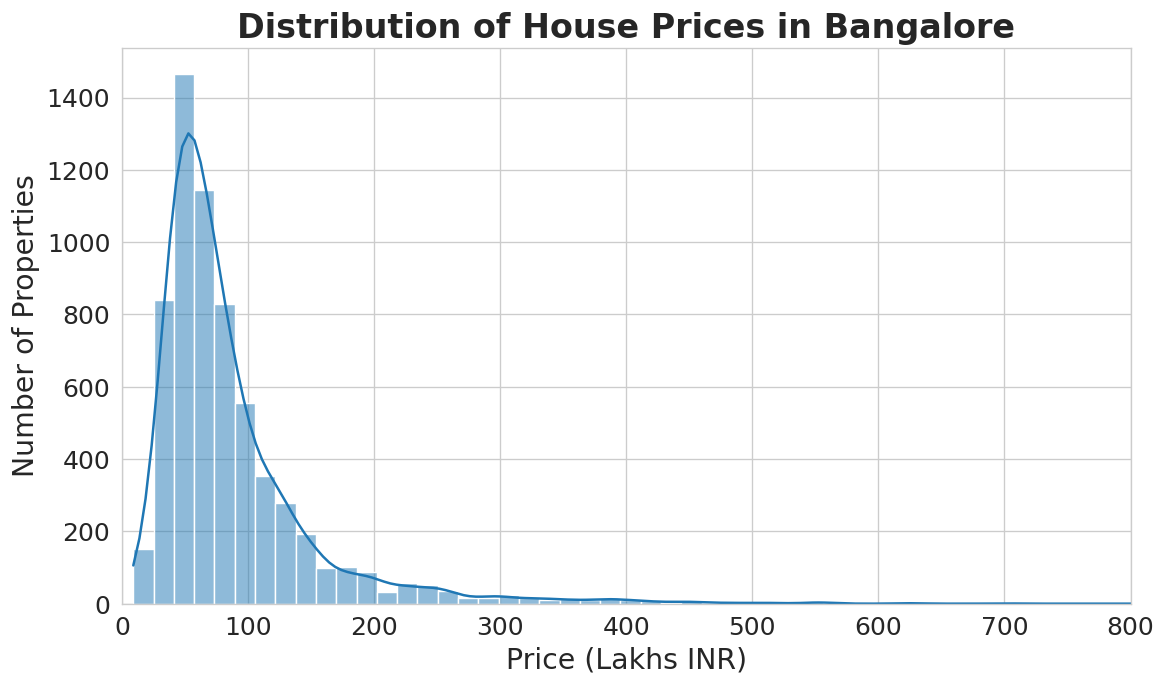

In [14]:
# Figure 4.1 — Price distribution
fig, ax = plt.subplots(figsize=(10, 6))
sns.histplot(df_spatial['price'], bins=60, kde=True, ax=ax)
ax.set_title('Distribution of House Prices in Bangalore')
ax.set_xlabel('Price (Lakhs INR)')
ax.set_ylabel('Number of Properties')
ax.set_xlim(0, 800)
plt.tight_layout()
plt.savefig('fig4_1_price_distribution.png', dpi=150)
plt.show()

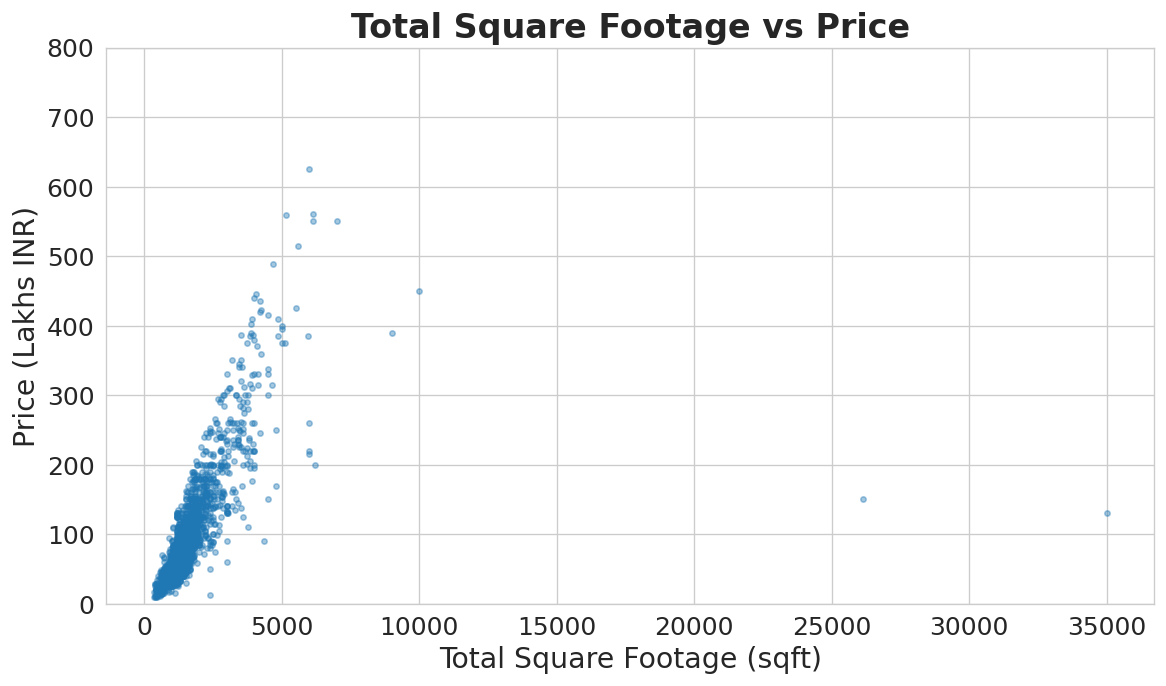

In [15]:
# Figure 4.2 — Sqft vs Price
fig, ax = plt.subplots(figsize=(10, 6))
sample = df_spatial.sample(min(3000, len(df_spatial)), random_state=42)
ax.scatter(sample['total_sqft_num'], sample['price'], alpha=0.4, s=10)
ax.set_title('Total Square Footage vs Price')
ax.set_xlabel('Total Square Footage (sqft)')
ax.set_ylabel('Price (Lakhs INR)')
ax.set_ylim(0, 800)
plt.tight_layout()
plt.savefig('fig4_2_sqft_vs_price.png', dpi=150)
plt.show()

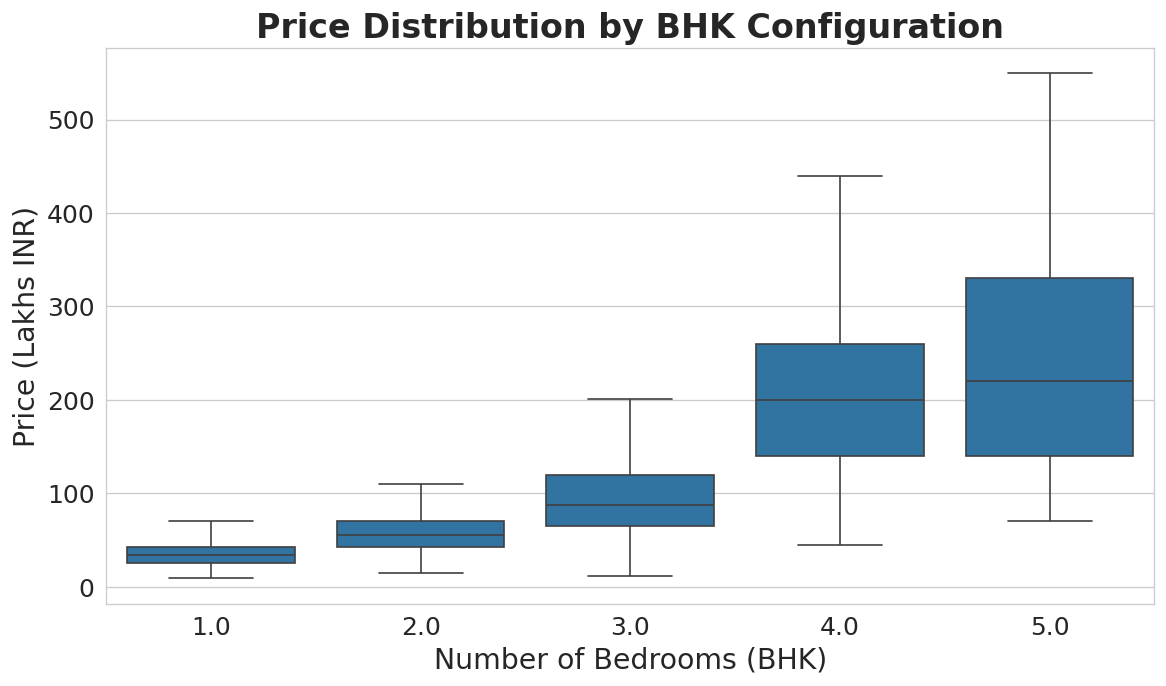

In [16]:
# Figure 4.3 — Price by BHK
fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(data=df_spatial[df_spatial['bhk']<=5], x='bhk', y='price', ax=ax, showfliers=False)
ax.set_title('Price Distribution by BHK Configuration')
ax.set_xlabel('Number of Bedrooms (BHK)')
ax.set_ylabel('Price (Lakhs INR)')
plt.tight_layout()
plt.savefig('fig4_3_price_by_bhk.png', dpi=150)
plt.show()

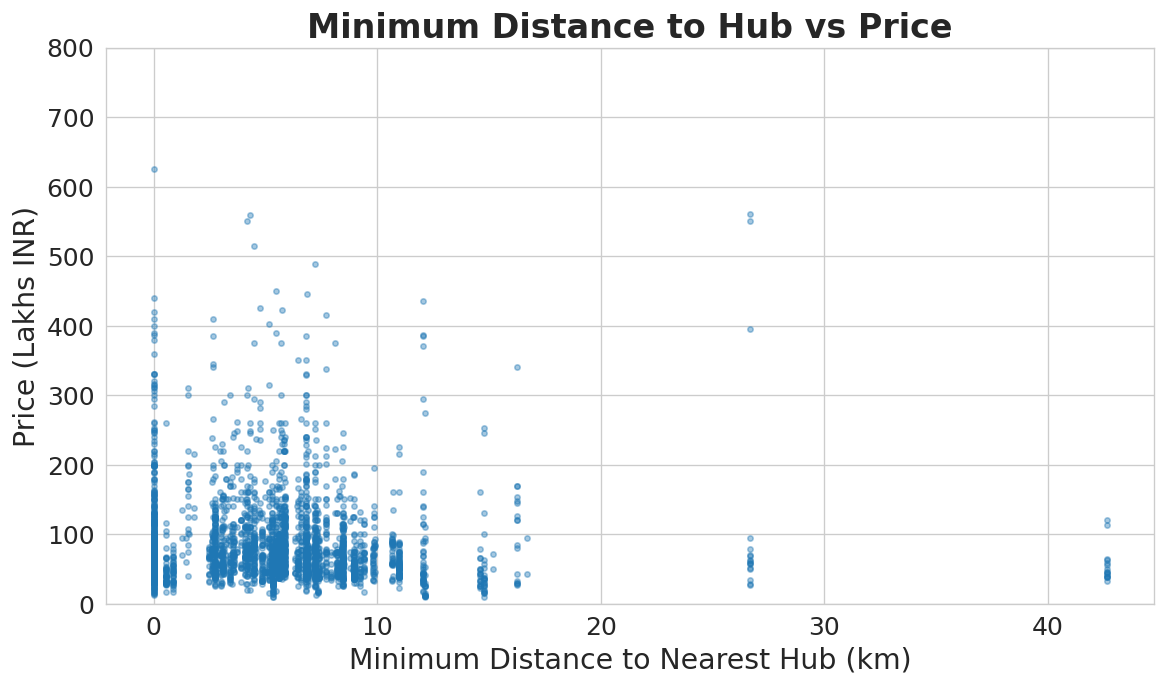

In [17]:
# Figure 4.4 — Distance to Hub vs Price
fig, ax = plt.subplots(figsize=(10, 6))
sample = df_spatial.sample(min(3000, len(df_spatial)), random_state=42)
ax.scatter(sample['min_dist_to_hub'], sample['price'], alpha=0.4, s=10)
ax.set_title('Minimum Distance to Hub vs Price')
ax.set_xlabel('Minimum Distance to Nearest Hub (km)')
ax.set_ylabel('Price (Lakhs INR)')
ax.set_ylim(0, 800)
plt.tight_layout()
plt.savefig('fig4_4_distance_vs_price.png', dpi=150)
plt.show()

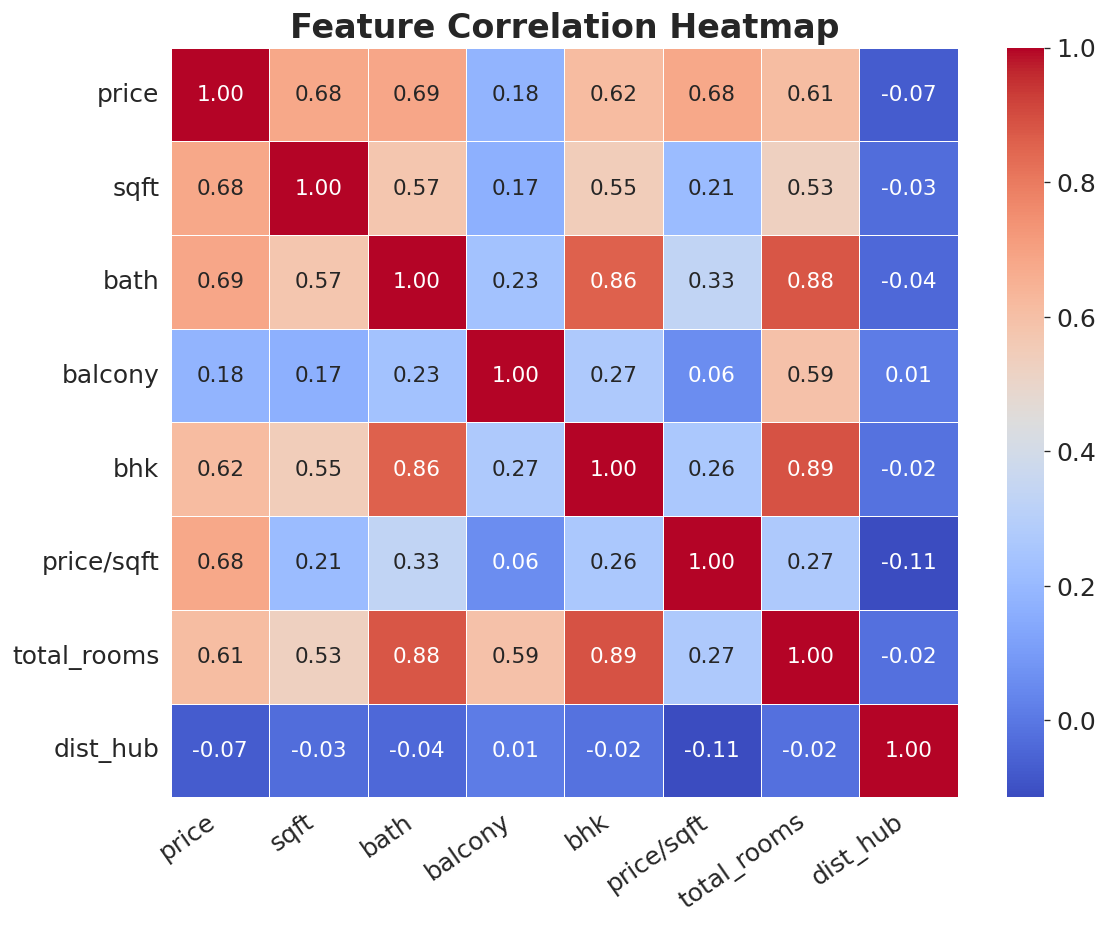

Note: price_per_sqft has very high correlation with price because it IS derived from price.
It is excluded from all models to prevent target leakage.


In [18]:
# Figure 4.5 — Correlation heatmap
# Note: price_per_sqft is included to show target leakage, but excluded from modelling
corr_cols = ['price','total_sqft_num','bath','balcony','bhk','price_per_sqft','total_rooms','min_dist_to_hub']
labels    = ['price','sqft','bath','balcony','bhk','price/sqft','total_rooms','dist_hub']
corr = df_spatial[corr_cols].corr()
corr.index = labels; corr.columns = labels

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', ax=ax,
            annot_kws={'size':13}, linewidths=0.5)
ax.set_title('Feature Correlation Heatmap')
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.savefig('fig4_5_correlation_heatmap.png', dpi=150)
plt.show()
print("Note: price_per_sqft has very high correlation with price because it IS derived from price.")
print("It is excluded from all models to prevent target leakage.")

In [19]:
df_spatial.to_csv('bengaluru_spatial_features.csv', index=False)
print("Saved: bengaluru_spatial_features.csv | shape:", df_spatial.shape)

Saved: bengaluru_spatial_features.csv | shape: (6439, 23)


---
## Section 3: Model Development and Evaluation

### 3.1 Load spatial dataset and select features

In [20]:
df_model = pd.read_csv('bengaluru_spatial_features.csv')
print("Shape:", df_model.shape)

# IMPORTANT: price_per_sqft is excluded to prevent target leakage.
# It is calculated FROM price so including it would give artificially perfect accuracy.
selected_columns = [
    'price', 'total_sqft_num', 'bath', 'balcony', 'bhk', 'total_rooms',
    'area_type', 'location_grouped', 'nearest_hub',
    'dist_MG_Road', 'dist_Whitefield', 'dist_Electronic_City',
    'dist_Koramangala', 'dist_Hebbal', 'min_dist_to_hub',
]

model_df = df_model[selected_columns].copy().dropna()
print("Modelling dataset shape:", model_df.shape)
print("Null values remaining:", model_df.isnull().sum().sum())
display(model_df.head())

Shape: (6439, 23)
Modelling dataset shape: (6439, 15)
Null values remaining: 0


,price,total_sqft_num,bath,balcony,bhk,total_rooms,area_type,location_grouped,nearest_hub,dist_MG_Road,dist_Whitefield,dist_Electronic_City,dist_Koramangala,dist_Hebbal,min_dist_to_hub
0,39.07,1056.0,2.0,1.0,2.0,5.0,Super built-up Area,Electronic City Phase II,Electronic_City,17.434900,16.984787,0.551715,12.471696,23.920857,0.551715
1,120.00,2600.0,5.0,3.0,4.0,12.0,Plot Area,Chikka Tirupathi,Whitefield,20.631904,7.312237,23.741619,20.344247,20.845408,7.312237
2,62.00,1440.0,2.0,3.0,3.0,8.0,Built-up Area,Uttarahalli,Koramangala,9.897794,23.053385,15.895807,8.950888,15.342595,8.950888
3,51.00,1200.0,2.0,1.0,2.0,5.0,Super built-up Area,Kothanur,Hebbal,9.215458,17.778024,25.231551,13.721561,3.031546,3.031546
4,38.00,1170.0,2.0,1.0,2.0,5.0,Super built-up Area,Whitefield,Whitefield,15.714157,0.000000,16.464116,14.123193,18.118594,0.000000


### 3.2 Train / test split (70/30)

In [21]:
from sklearn.model_selection import train_test_split

X = model_df.drop('price', axis=1)
y = model_df['price']

categorical_features = ['area_type', 'location_grouped', 'nearest_hub']
numerical_features   = [col for col in X.columns if col not in categorical_features]

print("Categorical features:", categorical_features)
print("Numerical features:  ", numerical_features)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)
print(f"\nTraining set: {X_train.shape}")
print(f"Test set:     {X_test.shape}")

Categorical features: ['area_type', 'location_grouped', 'nearest_hub']
Numerical features:   ['total_sqft_num', 'bath', 'balcony', 'bhk', 'total_rooms', 'dist_MG_Road', 'dist_Whitefield', 'dist_Electronic_City', 'dist_Koramangala', 'dist_Hebbal', 'min_dist_to_hub']

Training set: (4507, 14)
Test set:     (1932, 14)


### 3.3 Preprocessing pipeline

In [22]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler()),
])
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot',  OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
])
preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer,   numerical_features),
    ('cat', categorical_transformer, categorical_features),
])
print("Preprocessing pipeline ready.")

Preprocessing pipeline ready.


### 3.4 Import models

In [23]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, StackingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor
print("Models imported.")

Models imported.


### 3.5 Evaluation function

In [24]:
def evaluate_model(name, model, X_train, X_test, y_train, y_test):
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', model),
    ])
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    r2   = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae  = mean_absolute_error(y_test, y_pred)

    print(f"{'='*45}")
    print(f"  {name}")
    print(f"{'='*45}")
    print(f"  R²   : {r2:.4f}")
    print(f"  RMSE : {rmse:.4f} Lakhs")
    print(f"  MAE  : {mae:.4f} Lakhs")
    print()
    return {'Model': name, 'R2': r2, 'RMSE': rmse, 'MAE': mae, 'Pipeline': pipeline}

### 3.6 Train all four models

In [25]:
# Model 1: Linear Regression (baseline — no hyperparameters to tune)
lr_result = evaluate_model(
    'Linear Regression', LinearRegression(),
    X_train, X_test, y_train, y_test
)

  Linear Regression
  R²   : 0.6574
  RMSE : 39.2268 Lakhs
  MAE  : 22.3988 Lakhs



In [26]:
# Model 2: Random Forest
# n_estimators=200: 200 trees; max_depth=20: allows complex patterns without extreme overfitting
# min_samples_split=5, min_samples_leaf=2: regularisation to prevent tiny leaf nodes
rf_result = evaluate_model(
    'Random Forest',
    RandomForestRegressor(n_estimators=200, max_depth=20, min_samples_split=5,
                          min_samples_leaf=2, random_state=42, n_jobs=-1),
    X_train, X_test, y_train, y_test
)

  Random Forest
  R²   : 0.8340
  RMSE : 27.3079 Lakhs
  MAE  : 14.8392 Lakhs



In [27]:
# Model 3: XGBoost
# learning_rate=0.05: small steps to avoid overfitting; n_estimators=300: many correction rounds
# subsample=0.8, colsample_bytree=0.8: stochastic regularisation
xgb_result = evaluate_model(
    'XGBoost',
    XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=6,
                 subsample=0.8, colsample_bytree=0.8,
                 objective='reg:squarederror', random_state=42),
    X_train, X_test, y_train, y_test
)

  XGBoost
  R²   : 0.8386
  RMSE : 26.9263 Lakhs
  MAE  : 15.1550 Lakhs



In [28]:
# Model 4: Stacked Hybrid (RF + XGBoost base learners, Ridge meta-learner)
# cv=5: out-of-fold predictions ensure meta-learner never trains on same data as base models
base_estimators = [
    ('rf',  RandomForestRegressor(n_estimators=150, max_depth=18, min_samples_split=5,
                                   min_samples_leaf=2, random_state=42, n_jobs=-1)),
    ('xgb', XGBRegressor(n_estimators=200, learning_rate=0.05, max_depth=5,
                          subsample=0.8, colsample_bytree=0.8,
                          objective='reg:squarederror', random_state=42)),
]
stack_result = evaluate_model(
    'Stacked Hybrid Model',
    StackingRegressor(estimators=base_estimators, final_estimator=Ridge(), cv=5, passthrough=False),
    X_train, X_test, y_train, y_test
)

  Stacked Hybrid Model
  R²   : 0.8428
  RMSE : 26.5710 Lakhs
  MAE  : 15.0559 Lakhs



### 3.7 Results comparison

In [29]:
results_df = pd.DataFrame([
    {'Model': lr_result['Model'],    'R2': lr_result['R2'],
     'RMSE': lr_result['RMSE'],      'MAE': lr_result['MAE']},
    {'Model': rf_result['Model'],    'R2': rf_result['R2'],
     'RMSE': rf_result['RMSE'],      'MAE': rf_result['MAE']},
    {'Model': xgb_result['Model'],   'R2': xgb_result['R2'],
     'RMSE': xgb_result['RMSE'],     'MAE': xgb_result['MAE']},
    {'Model': stack_result['Model'], 'R2': stack_result['R2'],
     'RMSE': stack_result['RMSE'],   'MAE': stack_result['MAE']},
]).sort_values('R2', ascending=False).reset_index(drop=True)

results_df[['R2','RMSE','MAE']] = results_df[['R2','RMSE','MAE']].round(4)
print("Model Performance Summary (Test Set)")
display(results_df)

Model Performance Summary (Test Set)


,Model,R2,RMSE,MAE
0,Stacked Hybrid Model,0.8428,26.5710,15.0559
1,XGBoost,0.8386,26.9263,15.1550
2,Random Forest,0.8340,27.3079,14.8392
3,Linear Regression,0.6574,39.2268,22.3988


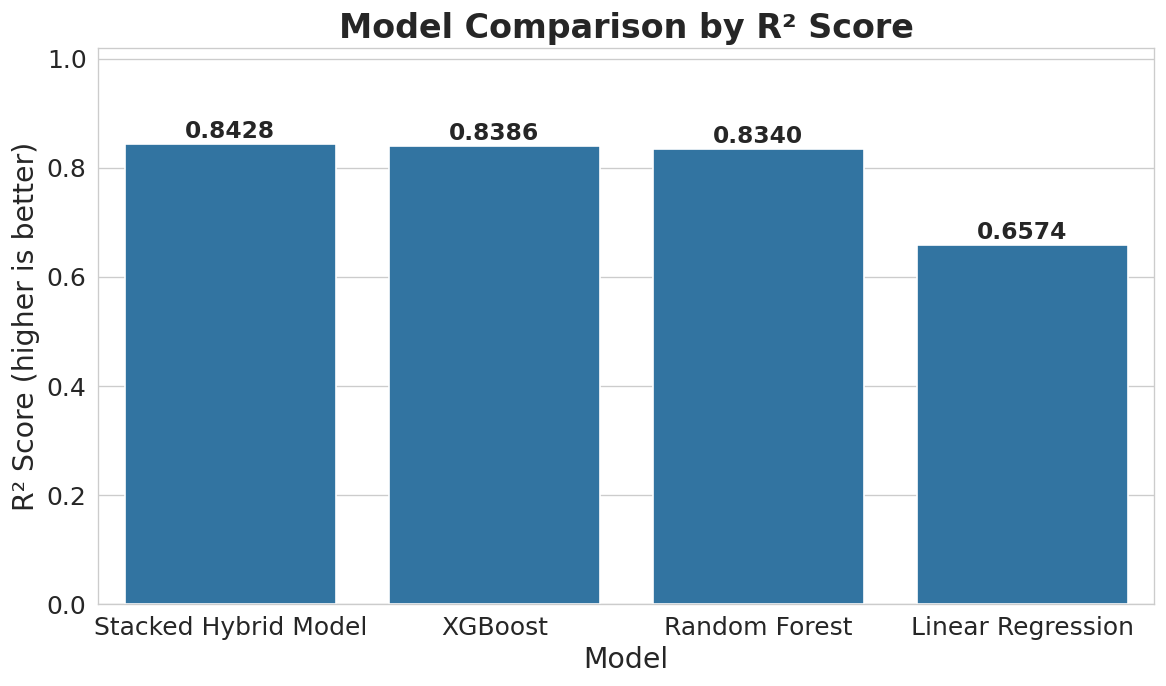

In [30]:
# Figure 5.1 — R squared comparison
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=results_df, x='Model', y='R2', ax=ax)
for p in ax.patches:
    ax.annotate(f'{p.get_height():.4f}',
                (p.get_x()+p.get_width()/2, p.get_height()+0.003),
                ha='center', va='bottom', fontsize=14, fontweight='bold')
ax.set_title('Model Comparison by R² Score')
ax.set_xlabel('Model'); ax.set_ylabel('R² Score (higher is better)')
ax.set_ylim(0, 1.02)
plt.tight_layout()
plt.savefig('fig5_1_r2_comparison.png', dpi=150)
plt.show()

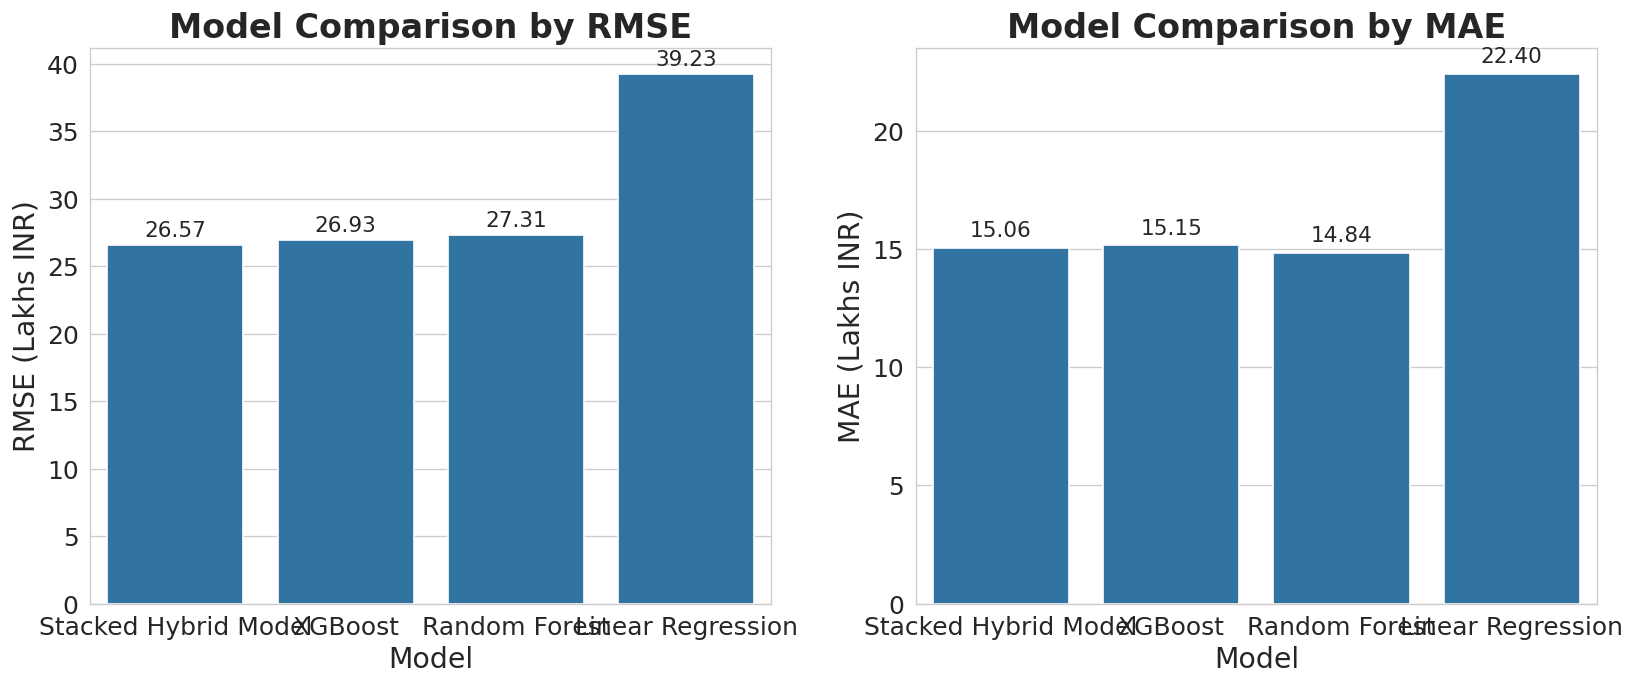

In [31]:
# Figure 5.2 — RMSE and MAE comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, metric, ylabel in [(axes[0],'RMSE','RMSE (Lakhs INR)'), (axes[1],'MAE','MAE (Lakhs INR)')]:
    sns.barplot(data=results_df, x='Model', y=metric, ax=ax)
    for p in ax.patches:
        ax.annotate(f'{p.get_height():.2f}',
                    (p.get_x()+p.get_width()/2, p.get_height()+0.3),
                    ha='center', va='bottom', fontsize=13)
    ax.set_title(f'Model Comparison by {metric}')
    ax.set_xlabel('Model'); ax.set_ylabel(ylabel)
plt.tight_layout()
plt.savefig('fig5_2_rmse_comparison.png', dpi=150)
plt.show()

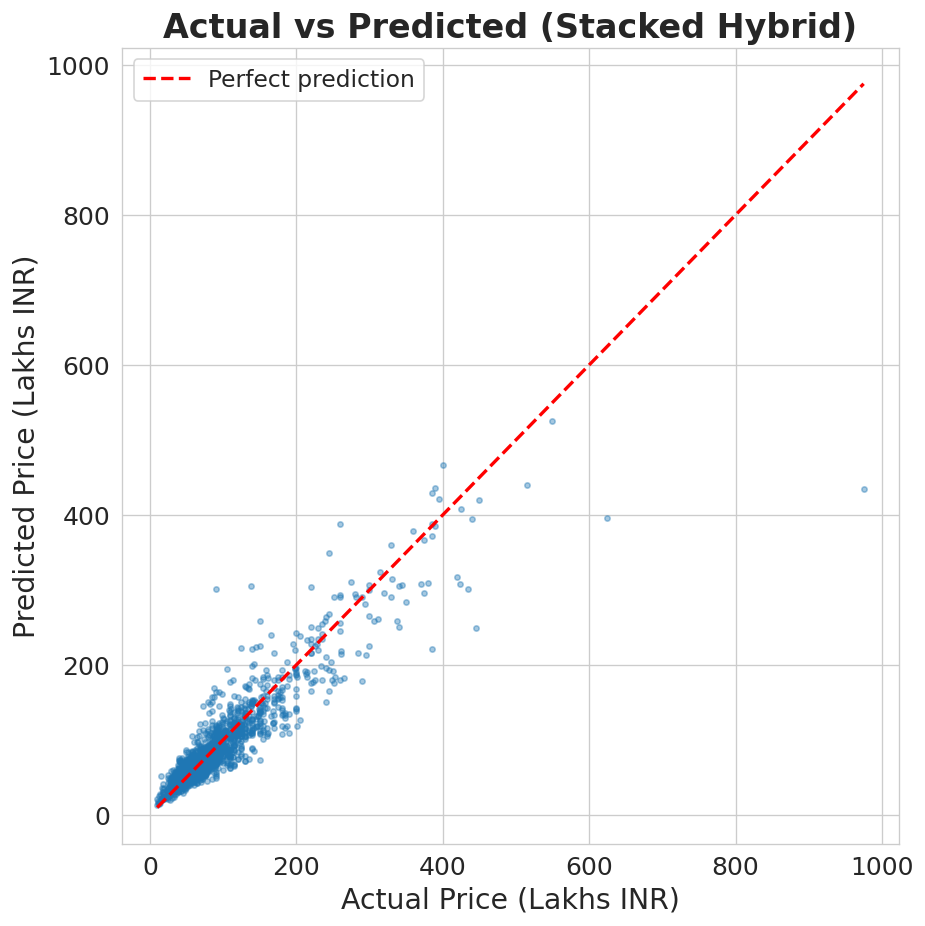

In [32]:
# Figure 5.3 — Actual vs Predicted (Stacked Hybrid)
y_pred_stack = stack_result['Pipeline'].predict(X_test)
fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(y_test, y_pred_stack, alpha=0.4, s=10)
ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect prediction')
ax.set_title('Actual vs Predicted (Stacked Hybrid)'); ax.legend()
ax.set_xlabel('Actual Price (Lakhs INR)'); ax.set_ylabel('Predicted Price (Lakhs INR)')
plt.tight_layout()
plt.savefig('fig5_3_actual_vs_pred_stacked.png', dpi=150)
plt.show()

In [33]:
results_df.to_csv('model_comparison_results.csv', index=False)
print("Saved: model_comparison_results.csv")

Saved: model_comparison_results.csv


---
## Section 4: Feature Importance and Model Interpretation

### 4.1 Retrain Random Forest for feature importance

In [34]:
best_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(n_estimators=200, max_depth=20,
                                     min_samples_split=5, min_samples_leaf=2,
                                     random_state=42, n_jobs=-1)),
])
best_pipeline.fit(X_train, y_train)
print("Random Forest retrained for feature importance analysis.")

Random Forest retrained for feature importance analysis.


### 4.2 Gini importance

In [35]:
ohe = best_pipeline.named_steps['preprocessor'].named_transformers_['cat'].named_steps['onehot']
cat_feature_names = ohe.get_feature_names_out(categorical_features)
all_feature_names = numerical_features + list(cat_feature_names)
print("Total features after encoding:", len(all_feature_names))

rf_model = best_pipeline.named_steps['model']
feature_importances = pd.DataFrame({
    'Feature':    all_feature_names,
    'Importance': rf_model.feature_importances_,
}).sort_values('Importance', ascending=False).reset_index(drop=True)

print("\nTop 20 features by Gini importance:")
display(feature_importances.head(20))

Total features after encoding: 121

Top 20 features by Gini importance:


,Feature,Importance
0,total_sqft_num,0.850912
1,dist_MG_Road,0.029725
2,total_rooms,0.014660
3,min_dist_to_hub,0.013235
4,dist_Hebbal,0.013066
5,bhk,0.011870
6,dist_Whitefield,0.011027
7,dist_Koramangala,0.009867
8,bath,0.008191
9,dist_Electronic_City,0.007585


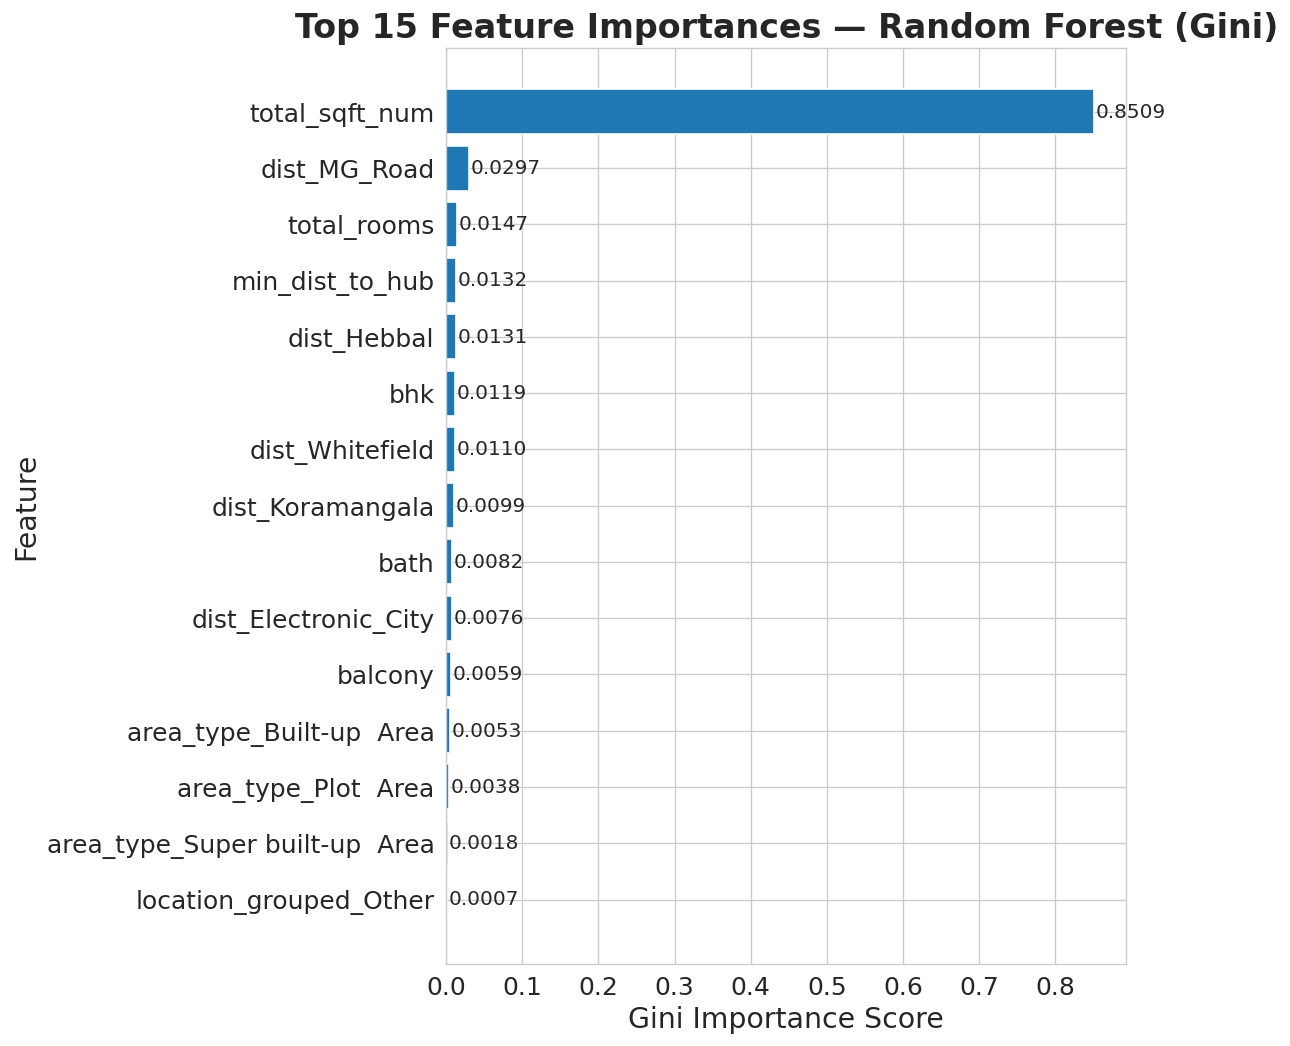

In [36]:
# Figure 5.4 — Top 15 features (Gini)
top15 = feature_importances.head(15).sort_values('Importance', ascending=True)
fig, ax = plt.subplots(figsize=(10, 9))
ax.barh(top15['Feature'], top15['Importance'])
ax.set_title('Top 15 Feature Importances — Random Forest (Gini)')
ax.set_xlabel('Gini Importance Score'); ax.set_ylabel('Feature')
for i, val in enumerate(top15['Importance']):
    ax.text(val+0.002, i, f'{val:.4f}', va='center', fontsize=12)
plt.tight_layout()
plt.savefig('fig5_4_feature_importance_raw.png', dpi=150)
plt.show()

### 4.3 Grouped importance

In [37]:
def group_feature(name):
    if name.startswith('location_grouped_'): return 'location_grouped'
    elif name.startswith('area_type_'):       return 'area_type'
    elif name.startswith('nearest_hub_'):     return 'nearest_hub'
    return name

feature_importances['Grouped_Feature'] = feature_importances['Feature'].apply(group_feature)
grouped_importance = (feature_importances
    .groupby('Grouped_Feature', as_index=False)['Importance'].sum()
    .sort_values('Importance', ascending=False).reset_index(drop=True))
display(grouped_importance)

,Grouped_Feature,Importance
0,total_sqft_num,0.850912
1,dist_MG_Road,0.029725
2,total_rooms,0.014660
3,min_dist_to_hub,0.013235
4,dist_Hebbal,0.013066
5,bhk,0.011870
6,dist_Whitefield,0.011027
7,area_type,0.010934
8,location_grouped,0.010730
9,dist_Koramangala,0.009867


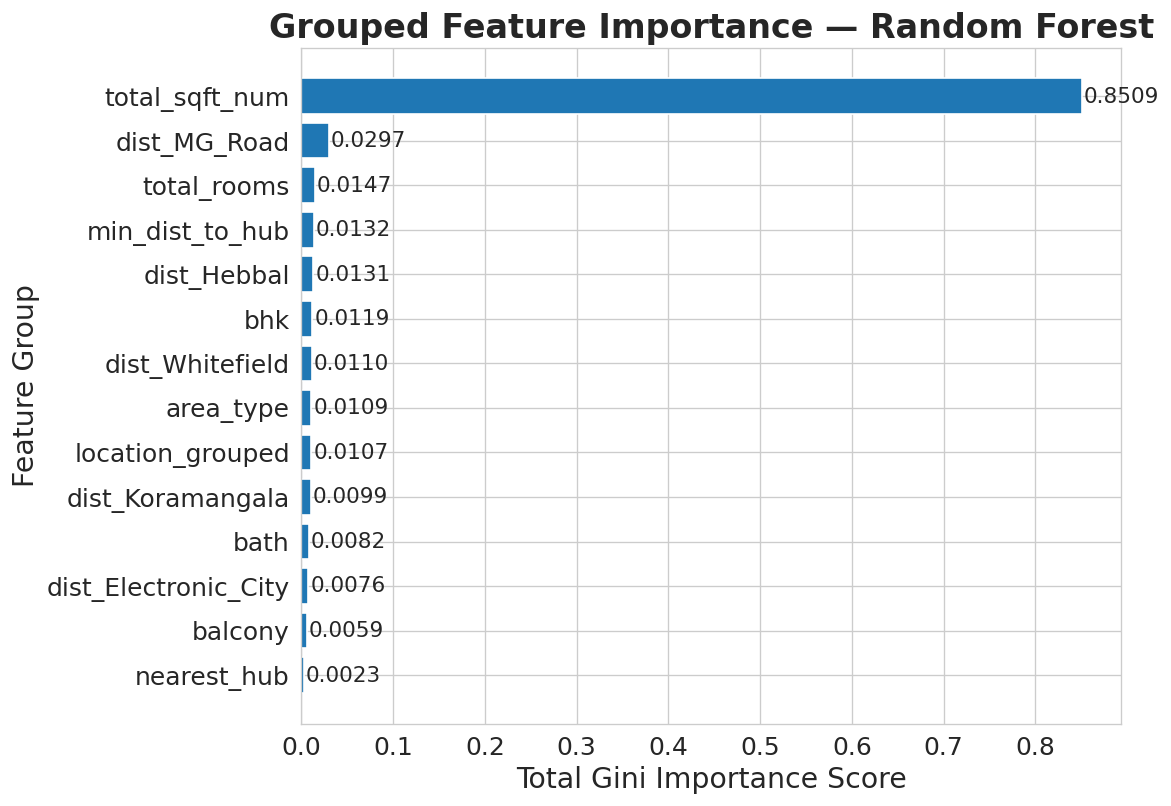

In [38]:
# Figure 5.5 — Grouped importance
grp = grouped_importance.sort_values('Importance', ascending=True)
fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(grp['Grouped_Feature'], grp['Importance'])
ax.set_title('Grouped Feature Importance — Random Forest')
ax.set_xlabel('Total Gini Importance Score'); ax.set_ylabel('Feature Group')
for i, val in enumerate(grp['Importance']):
    ax.text(val+0.002, i, f'{val:.4f}', va='center', fontsize=13)
plt.tight_layout()
plt.savefig('fig5_5_feature_importance_grouped.png', dpi=150)
plt.show()

### 4.4 Permutation importance

In [39]:
from sklearn.inspection import permutation_importance

perm_result = permutation_importance(best_pipeline, X_test, y_test,
                                      n_repeats=10, random_state=42, n_jobs=-1)
perm_importance_df = pd.DataFrame({
    'Feature':    X_test.columns,
    'Importance': perm_result.importances_mean,
}).sort_values('Importance', ascending=False).reset_index(drop=True)

print("Permutation importance (top 15):")
display(perm_importance_df.head(15))

Permutation importance (top 15):


,Feature,Importance
0,total_sqft_num,1.381593
1,dist_MG_Road,0.027702
2,bhk,0.017956
3,area_type,0.008825
4,min_dist_to_hub,0.007491
5,total_rooms,0.005825
6,dist_Hebbal,0.005823
7,bath,0.005813
8,dist_Whitefield,0.003039
9,location_grouped,0.002412


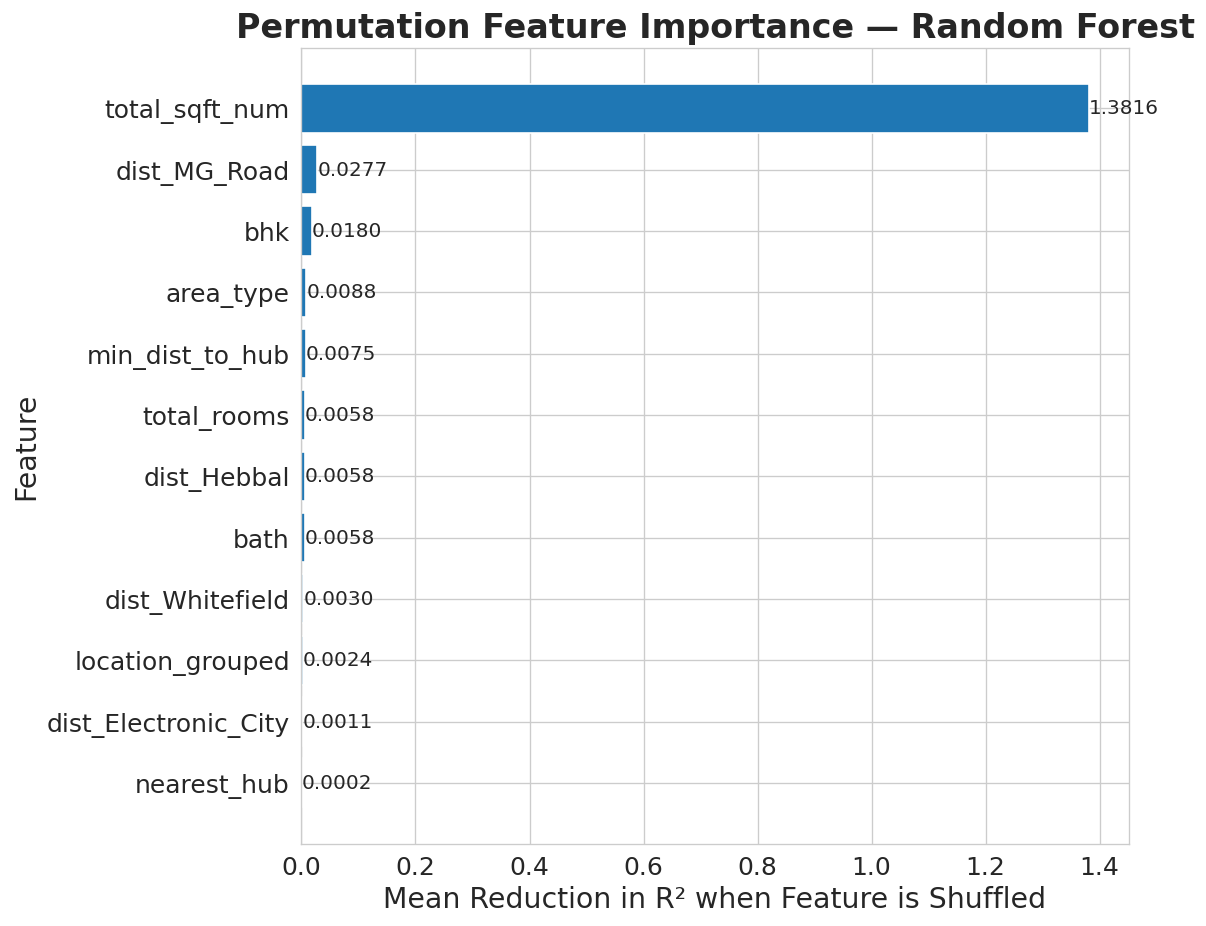

In [40]:
# Figure 5.6 — Permutation importance
top_perm = perm_importance_df.head(12).sort_values('Importance', ascending=True)
fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(top_perm['Feature'], top_perm['Importance'])
ax.set_title('Permutation Feature Importance — Random Forest')
ax.set_xlabel('Mean Reduction in R² when Feature is Shuffled'); ax.set_ylabel('Feature')
for i, val in enumerate(top_perm['Importance']):
    ax.text(val+0.0002, i, f'{val:.4f}', va='center', fontsize=12)
plt.tight_layout()
plt.savefig('fig5_6_permutation_importance.png', dpi=150)
plt.show()

### 4.5 Residual analysis — Random Forest

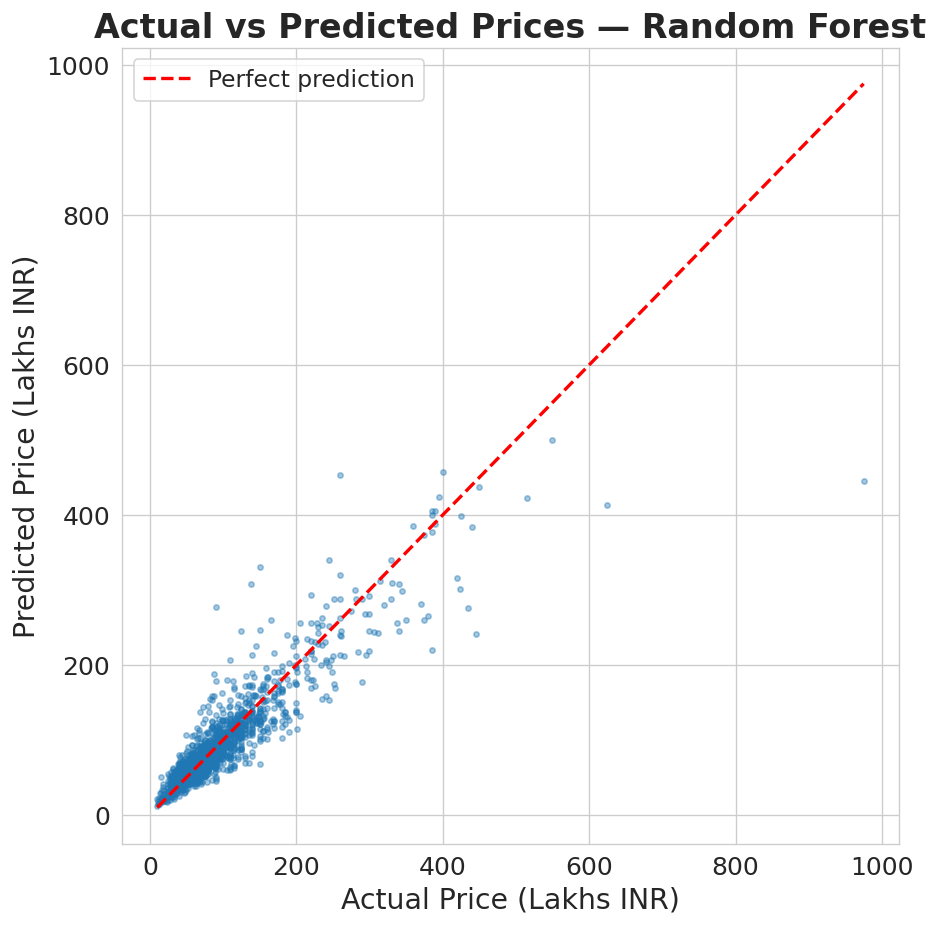

In [41]:
y_pred_rf = best_pipeline.predict(X_test)

# Figure 5.7 — Actual vs Predicted (RF)
fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(y_test, y_pred_rf, alpha=0.4, s=10)
ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect prediction')
ax.set_title('Actual vs Predicted Prices — Random Forest'); ax.legend()
ax.set_xlabel('Actual Price (Lakhs INR)'); ax.set_ylabel('Predicted Price (Lakhs INR)')
plt.tight_layout()
plt.savefig('fig5_7_actual_vs_pred_rf.png', dpi=150)
plt.show()

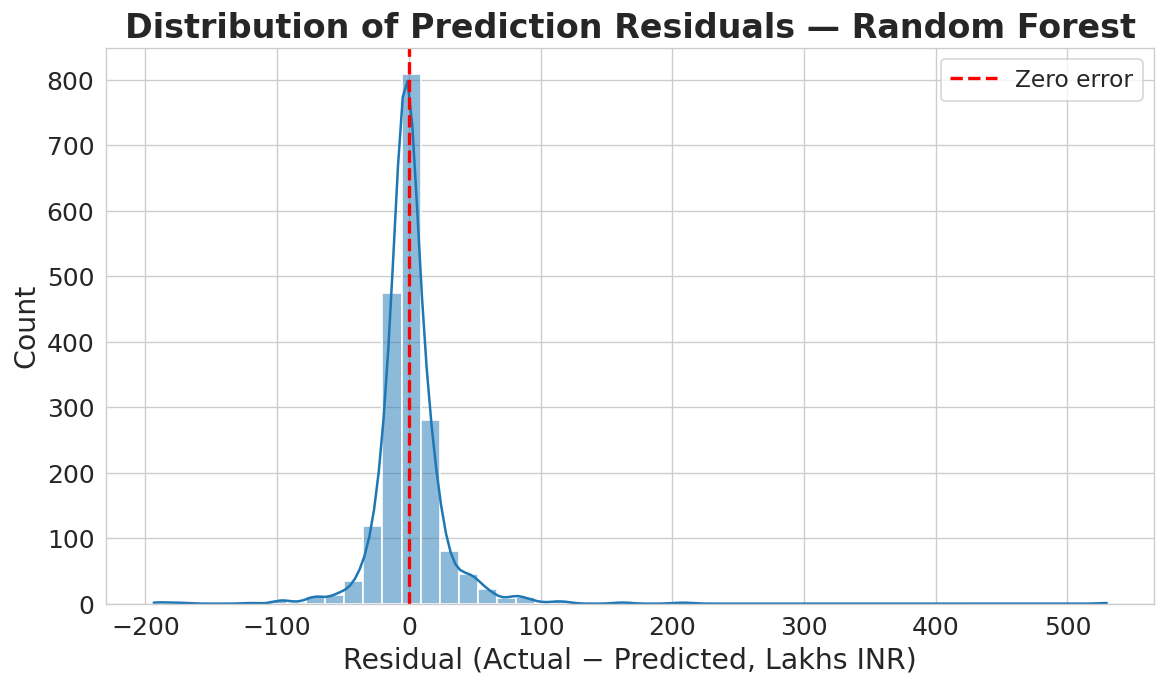

In [42]:
residuals = y_test - y_pred_rf

# Figure 5.8 — Residual distribution
fig, ax = plt.subplots(figsize=(10, 6))
sns.histplot(residuals, bins=50, kde=True, ax=ax)
ax.axvline(0, color='red', linestyle='--', lw=2, label='Zero error')
ax.set_title('Distribution of Prediction Residuals — Random Forest')
ax.set_xlabel('Residual (Actual − Predicted, Lakhs INR)'); ax.set_ylabel('Count'); ax.legend()
plt.tight_layout()
plt.savefig('fig5_8_residual_distribution.png', dpi=150)
plt.show()

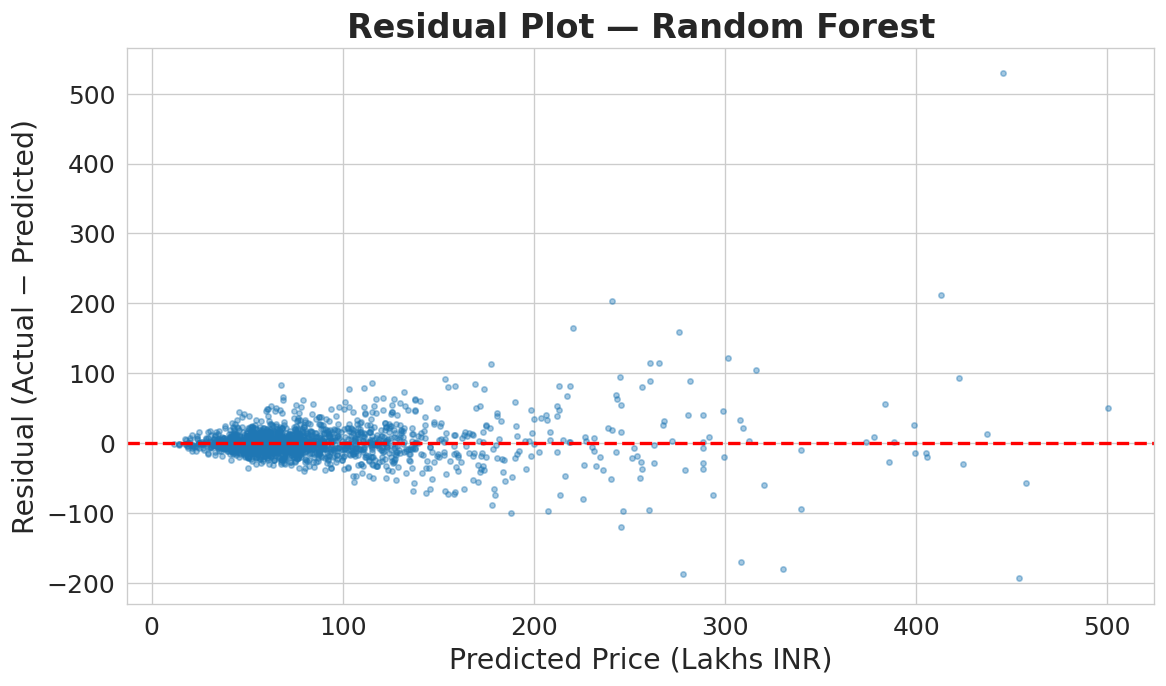

Mean residual: 0.54 Lakhs (should be near 0)
Std residuals: 27.31 Lakhs


In [43]:
# Figure 5.9 — Residual plot
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(y_pred_rf, residuals, alpha=0.4, s=10)
ax.axhline(0, color='red', linestyle='--', lw=2)
ax.set_title('Residual Plot — Random Forest')
ax.set_xlabel('Predicted Price (Lakhs INR)'); ax.set_ylabel('Residual (Actual − Predicted)')
plt.tight_layout()
plt.savefig('fig5_9_residual_plot.png', dpi=150)
plt.show()
print(f"Mean residual: {residuals.mean():.2f} Lakhs (should be near 0)")
print(f"Std residuals: {residuals.std():.2f} Lakhs")

### 4.6 Save all outputs

In [44]:
feature_importances.to_csv('rf_feature_importance_raw.csv', index=False)
grouped_importance.to_csv('rf_feature_importance_grouped.csv', index=False)
perm_importance_df.to_csv('rf_permutation_importance.csv', index=False)

print("All files saved:")
print("  bengaluru_cleaned_stage1.csv")
print("  bengaluru_spatial_features.csv")
print("  model_comparison_results.csv")
print("  rf_feature_importance_raw.csv")
print("  rf_feature_importance_grouped.csv")
print("  rf_permutation_importance.csv")
print("  fig4_1 through fig5_9 (PNG charts)")
print()
print("Final model results:")
display(results_df)

All files saved:
  bengaluru_cleaned_stage1.csv
  bengaluru_spatial_features.csv
  model_comparison_results.csv
  rf_feature_importance_raw.csv
  rf_feature_importance_grouped.csv
  rf_permutation_importance.csv
  fig4_1 through fig5_9 (PNG charts)

Final model results:


,Model,R2,RMSE,MAE
0,Stacked Hybrid Model,0.8428,26.5710,15.0559
1,XGBoost,0.8386,26.9263,15.1550
2,Random Forest,0.8340,27.3079,14.8392
3,Linear Regression,0.6574,39.2268,22.3988


In [45]:
import zipfile
import os
from google.colab import files

# Create a zip of all figures
with zipfile.ZipFile('thesis_charts_v2.zip', 'w') as zipf:
    for fname in sorted(os.listdir('.')):
        if fname.startswith('fig') and fname.endswith('.png'):
            zipf.write(fname)
            print(f"Added: {fname}")

print("\nZip created. Downloading...")
files.download('thesis_charts_v2.zip')

Added: fig4_1_price_distribution.png
Added: fig4_2_sqft_vs_price.png
Added: fig4_3_price_by_bhk.png
Added: fig4_4_distance_vs_price.png
Added: fig4_5_correlation_heatmap.png
Added: fig5_1_r2_comparison.png
Added: fig5_2_rmse_comparison.png
Added: fig5_3_actual_vs_pred_stacked.png
Added: fig5_4_feature_importance_raw.png
Added: fig5_5_feature_importance_grouped.png
Added: fig5_6_permutation_importance.png
Added: fig5_7_actual_vs_pred_rf.png
Added: fig5_8_residual_distribution.png
Added: fig5_9_residual_plot.png

Zip created. Downloading...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>